In [6]:
#import nessesary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from datetime import datetime



from sklearn.preprocessing import LabelEncoder, MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data set link:https://www.kaggle.com/code/mohaiminul101/car-price-prediction/input?select=car+data.csv

Attributes details

1.Car_Name:Name of the car

2.Year: year in which the car was bought.

3.Selling_Price: price the owner wants to sell the car at.

4.Present_Price: the current ex-showroom price of the car.

5.Kms_Driven:This is the distance completed by the car in km.

6.Fuel_Type:Fuel type of the car.

7.Seller_Type:Defines whether the seller is a dealer or an individual.

8.Transmission:Defines whether the car is manual or automatic

9.Owner: number of owners the car has previously had.

In [ ]:
# reading and analysing the dataset

In [7]:
df=pd.read_csv("cardata.csv")

In [8]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
df['Owner'].unique()

array([0, 1, 3])

In [10]:
df.shape

(301, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# handling misssing values

In [12]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Initial Observations:

The dataset has 301 rows and 9 columns. No missing values in any column.

The target variable is "Selling_Price".

Car_Name might not be useful for prediction and could be dropped.
Year represents the car's manufacturing year, which can be converted into the car's age.
Kms_Driven might need scaling due to its numeric nature.

In [ ]:
# ploting histogram

In [13]:
cols = df.select_dtypes(include=np.number)
cols.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')

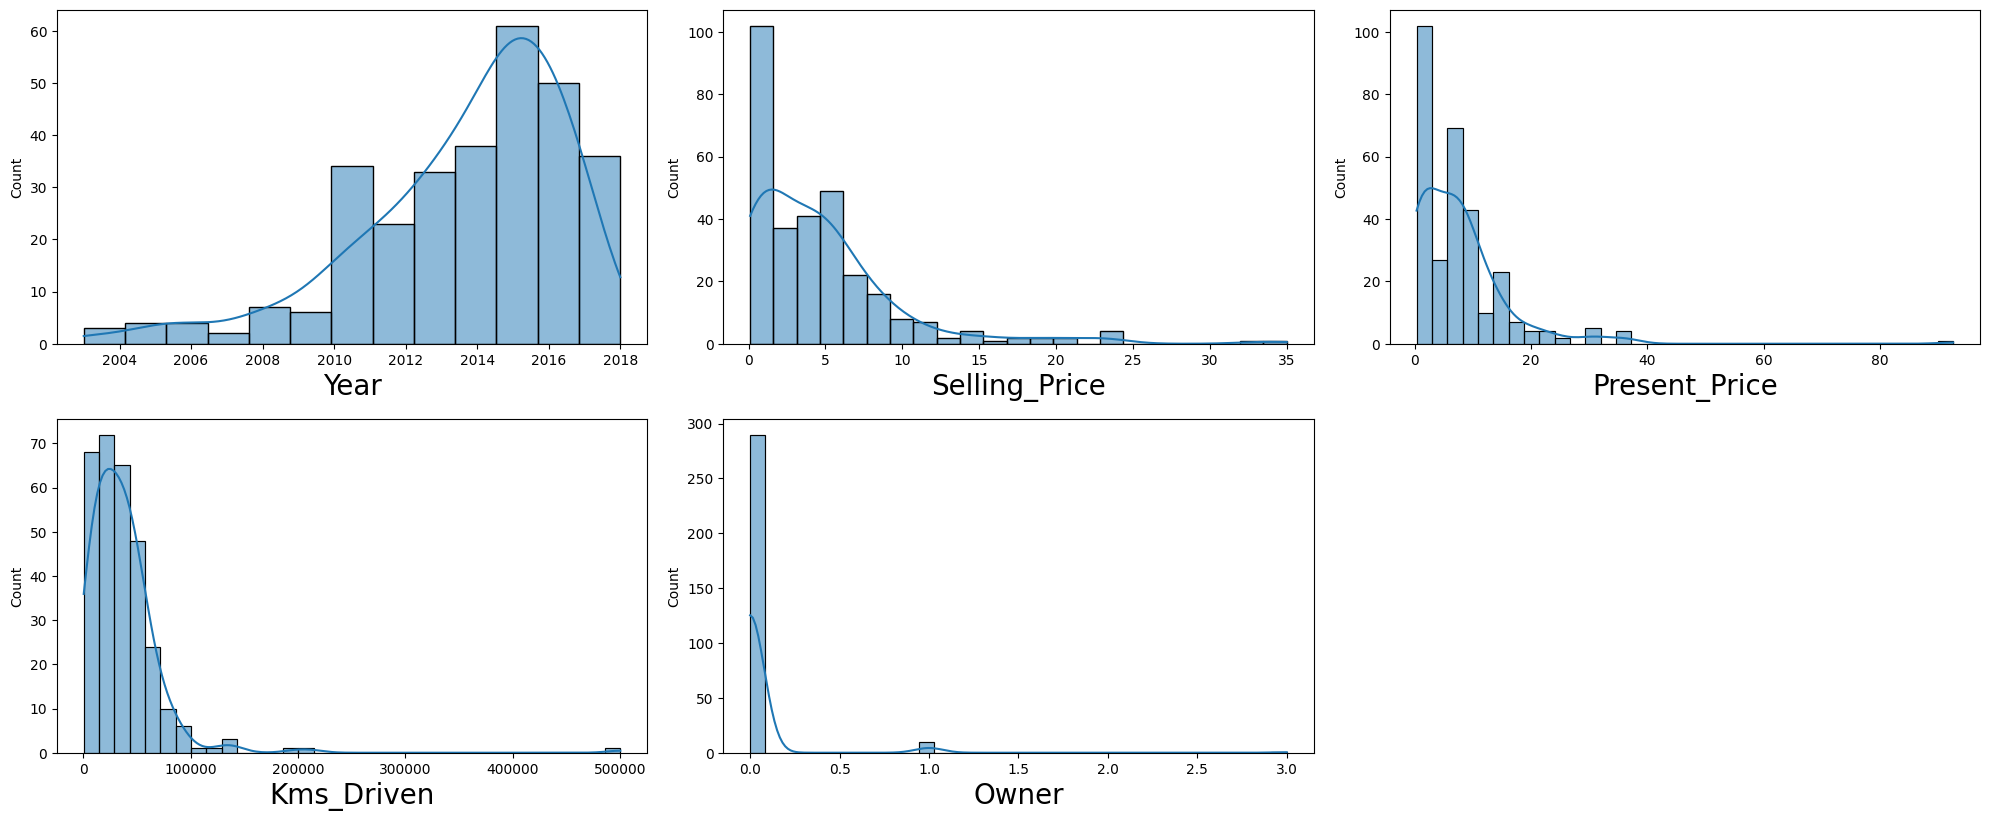

In [14]:
plt.figure(figsize=(20,20))
plotnumber =1
for column in cols:
    if plotnumber<=15:
        ax=plt.subplot(5,3,plotnumber)
        sns.histplot(cols[column],kde=True)
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.tight_layout()

# Handling outliers

In [15]:
outlier_cols = df.select_dtypes(include=np.number)
outlier_cols.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')

In [16]:
outlier_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven']

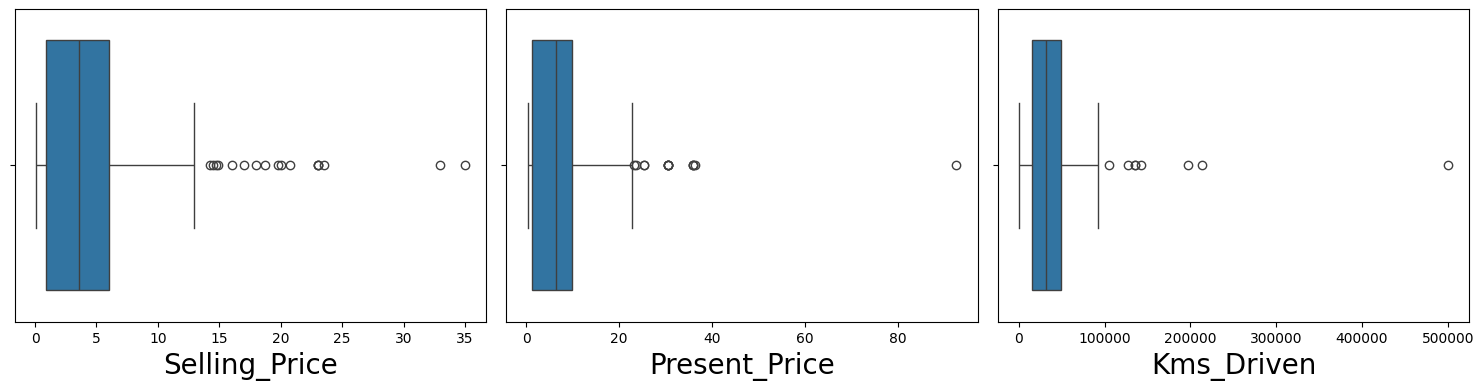

In [17]:
plt.figure(figsize=(15,15))
plotnumber =1
for column in outlier_cols:
    if plotnumber<=15:
        ax=plt.subplot(4,3,plotnumber)
        sns.boxplot(x=column,data=df)
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [18]:
def remove_outliers_iqr(data, column):
  q1,q2,q3 = np.percentile(data[column],[25,50,75])
  print("q1,q2,q3 is :",q1,q2,q3)
  IQR = q3-q1
  print("IQR is :" ,IQR)
  lower_limit = q1-(1.5*IQR)
  upper_limit = q3+(1.5*IQR)
  data[column]=np.where(data[column]>upper_limit,upper_limit,data[column]) # Capping the upper limit
  data[column]=np.where(data[column]<lower_limit,lower_limit,data[column]) # Flooring the lower limit

In [19]:
for column in outlier_cols:
  remove_outliers_iqr(df,column)

q1,q2,q3 is : 0.9 3.6 6.0
IQR is : 5.1
q1,q2,q3 is : 1.2 6.4 9.9
IQR is : 8.700000000000001
q1,q2,q3 is : 15000.0 32000.0 48767.0
IQR is : 33767.0


# Feature Engineering

In [20]:
# Step 1: Drop 'Car_Name' column
df.drop(columns=['Car_Name'], inplace=True)

In [21]:
current_year = datetime.now().year
current_year

2025

In [22]:
# Step 2: Convert 'Year' into 'Car_Age'
current_year = datetime.now().year
df['Car_Age'] = current_year - df['Year']
df.drop(columns=['Year'], inplace=True)  # Drop original 'Year' column

In [23]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000.0,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000.0,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900.0,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200.0,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450.0,Diesel,Dealer,Manual,0,11


# encoding

In [24]:
categorical_cols = df.select_dtypes(include='object')
categorical_cols.columns

Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')

In [25]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [26]:
df['Seller_Type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [27]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [28]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler,StandardScaler

In [29]:
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])  # Label Encoding for Seller_Type
df['Transmission'] = le.fit_transform(df['Transmission'])  # Label Encoding for Transmission
df = pd.get_dummies(df, columns=['Seller_Type'], drop_first=True)  # One-Hot Encoding for Fuel_Type

In [30]:
#pd.get_dummies(df, columns=['Seller_Type'], drop_first=True,dtype='int')

In [31]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Transmission,Owner,Car_Age,Seller_Type_Individual
0,3.35,5.59,27000.0,2,1,0,11,False
1,4.75,9.54,43000.0,1,1,0,12,False
2,7.25,9.85,6900.0,2,1,0,8,False
3,2.85,4.15,5200.0,2,1,0,14,False
4,4.60,6.87,42450.0,1,1,0,11,False


In [32]:
df['Transmission'].unique()

array([1, 0])

In [33]:
df.shape

(301, 8)

# feature selection

<Axes: >

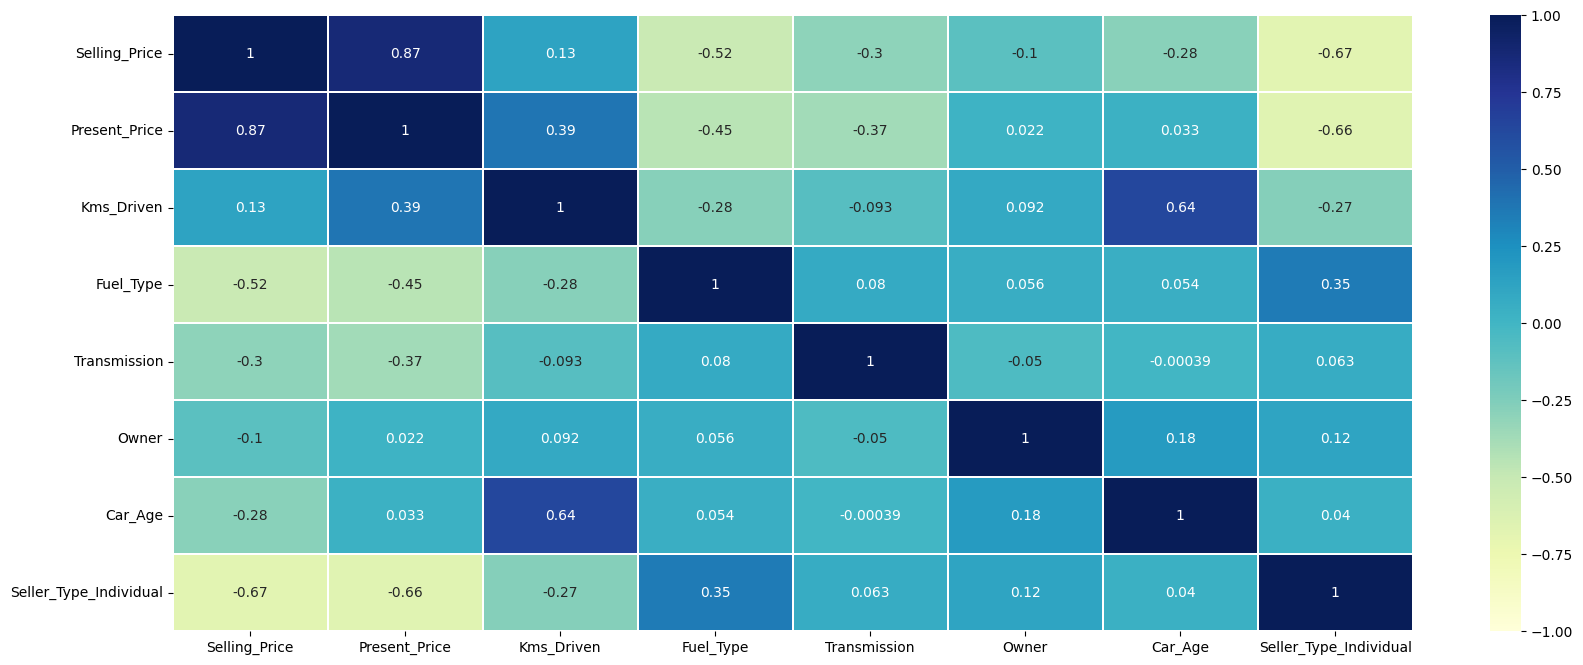

In [34]:
corrmatrix=df.corr()
plt.subplots(figsize=(20,8))
sns.heatmap(corrmatrix,vmin=-1,vmax=1,annot=True,linewidth=.2,cmap='YlGnBu')

In [36]:
#splitting data into dependent and independent columns
x=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

# Scaling

In [ ]:
# #standard scaling
# from sklearn import preprocessing
# standadisation=StandardScaler()
# x=standadisation.fit_transform(x)
# # Coverting to Dataframe
# x=pd.DataFrame(x)
# x.describe()

In [37]:
#from sklearn import preprocessing
normalisation = MinMaxScaler()
x=normalisation.fit_transform(x)
# Coverting to Dataframe
x=pd.DataFrame(x)
x.describe()

,0,1,2,3,4,5,6
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,0.298567,0.342979,0.893688,0.867110,0.014396,0.291473,0.352159
std,0.272315,0.239861,0.212901,0.340021,0.082638,0.192770,0.478439
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.038886,0.146587,1.000000,1.000000,0.000000,0.133333,0.000000
50%,0.268670,0.318447,1.000000,1.000000,0.000000,0.266667,0.000000
75%,0.423332,0.487952,1.000000,1.000000,0.000000,0.400000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# train test split

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state =42,test_size=0.33)

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
##  Train a Baseline Model (Linear Regression)
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# prediction
y_pred = lr_model.predict(x_test)
y_pred

array([ 0.81790882,  8.8359845 ,  5.8593262 , -1.43033347, 10.17879371,
        6.69905971,  1.34776734,  0.96613591,  1.30611934,  6.90243673,
        8.51729039,  0.68041168,  7.02040715,  1.34756245,  6.32876651,
        2.87175385,  0.78508276, 11.73309509,  1.66222749,  2.40191497,
        0.54983407,  7.50766066,  6.18607698,  2.8639033 ,  0.82170582,
        3.89983611,  5.52669332,  2.96064054,  2.10956646,  1.74991387,
        0.53176643,  8.76141379, -0.3917993 ,  2.643007  ,  7.94040445,
        4.59196355,  7.79093382,  8.74965073,  2.71659269,  9.14787148,
        4.91540125,  3.2587912 ,  4.47396531,  0.52894791,  6.64601934,
        0.55411879,  7.90718571, 10.60243696,  3.13109124,  4.61726088,
        5.12750204,  2.19102395, 13.43486281, 14.3973543 ,  6.72009934,
        8.21705522,  4.57956466,  8.46108999,  2.37751343,  5.79380578,
        0.26061498, -2.10909546,  1.93214007, -1.33141236,  4.77022187,
        1.8597044 , 13.2133366 , 13.51750084,  5.64846991, -0.74

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
# evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [45]:
mae           # lower better   here good

1.0263378233364513

In [46]:
mse            # lower better   here good

2.043545221960614

In [47]:
r2               #higher better    here good

0.8627268806199775

# polynomial regression

In [41]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# fit learns how to expand the features (e.g., squares, cross-products, etc.).
# transform applies that expansion to the actual data.
# you must learn (fit) only from the training data.
# include_bias=False
# By default, PolynomialFeatures adds a column of 1’s (bias term).
#Setting it to False removes this extra column.

In [42]:
# Apply polynomial transformation (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [43]:
# Fit polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict and evaluate
y_pred_poly = poly_model.predict(X_test_poly)

# Performance
print("Polynomial Regression (Degree 2):")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R² Score:", r2_score(y_test, y_pred_poly))


Polynomial Regression (Degree 2):
MSE: 1.0396892618677034
R² Score: 0.930159907092458


# check over and underfitting

In [44]:
#predict on both training and test sets
y_pred_train = lr_model.predict(x_train)
y_pred_test = lr_model.predict(x_test)

In [45]:
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

In [46]:
r2_train                                    #90       70

0.8903177955567082

In [47]:
r2_test                                      #70        68(underfitting)

0.864079013568099

In [ ]:
#its ok . no overfitting or underfitting

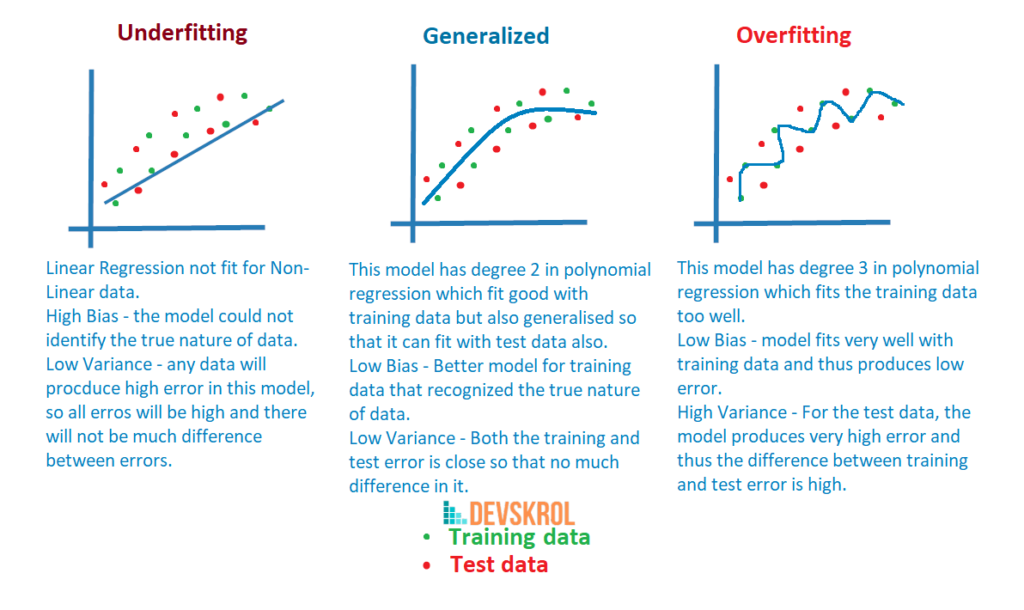

In [ ]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=1.0)# hyper parameter
ridge.fit(x_train,y_train)

Ridge()

In [ ]:
# prediction
y_train_pred_ridge = ridge.predict(x_train)
y_test_pred_ridge = ridge.predict(x_test)

In [ ]:
# evaluation
from sklearn.metrics import mean_squared_error
mse_train_ridge = mean_squared_error(y_train,y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test,y_test_pred_ridge)

In [ ]:
mse_train_ridge

1.584175576353142

In [ ]:
mse_test_ridge

1.8080722813153962

In [ ]:
r2_score(y_train,y_train_pred_ridge)

0.883310433881199

In [ ]:
r2_score(y_test,y_test_pred_ridge)

0.8785445413913616

In [ ]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train,y_train)

Lasso()

In [ ]:
#predictions
y_train_pred_lasso = lasso.predict(x_train)
y_test_pred_lasso = lasso.predict(x_test)

In [ ]:
mse_train_lasso = mean_squared_error(y_train,y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test,y_test_pred_lasso)

In [ ]:
r2_score(y_train,y_train_pred_lasso)

0.12050287887017608

In [ ]:
r2_score(y_test,y_test_pred_lasso)

0.12009836621309045

In [ ]:
from sklearn.svm import SVR
svr = SVR()
svr.fit(x_train,y_train)
y_pred = svr.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.8911858412862641

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(x_train,y_train)
y_pred = dtr.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.9091354011832331

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.fit(x_train,y_train)
y_pred=rfr.predict(x_test)


In [ ]:
r2_score(y_test,y_pred)

0.9518172397283933